# ML Model Comparison — Layer 3: Inverse ATS Matching
## Kilani Groupe — PFE Experimentation Report

**Objective:** Compare three candidate ranking strategies that, given a job offer,
return an ordered shortlist of eligible candidates from the CV pool.

**Strategies compared:**
1. `ATS-M1` — Rank by M1 score (rule-based weighted scoring)
2. `ATS-M2` — Rank by M2 score (semantic embeddings)
3. `ATS-M3` — Rank by M3 score (hybrid, recommended production model)

**Metrics:** Precision@K, Recall@K, NDCG@K, MAP, Kendall tau (ranking agreement)

---

**Notebook structure:**
1. Installation & Imports
2. Constants
3. Data Structures
4. Dataset Loading
5. Scoring Engines (re-used from Layer 2)
6. Inverse Matching — ATS Pipeline
7. Evaluation Dataset Construction
8. Retrieval Metrics (Precision@K, Recall@K, NDCG@K, MAP)
9. Ranking Quality (Kendall tau, rank correlation)
10. Comparative Visualisations
11. Per-Offer Shortlist Analysis
12. Threshold Sensitivity Analysis
13. Multi-Criteria Analysis & Final Decision
14. Summary (for Report)
15. Export & Download


---
## 1. Installation & Imports


In [1]:
!pip install -q kagglehub sentence-transformers scikit-learn
!pip install -q pandas numpy matplotlib seaborn scipy tqdm


In [18]:
import os, re, math, json as _json, time, warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'DejaVu Sans',
                     'axes.titlesize': 12, 'axes.labelsize': 10})

SAVE_DIR = './layer3_figures'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Imports OK')


Imports OK


---
## 2. Constants


In [19]:
WEIGHTS = {
    'technical_skills': 0.35,
    'experience':       0.25,
    'education':        0.20,
    'semantic':         0.12,
    'completeness':     0.08,
}

DIPLOMA_LEVELS = {
    'bac': 1, 'bac+2': 3, 'bts': 3, 'dut': 3,
    'licence': 4, 'bac+3': 4, 'bachelor': 4,
    'master': 5, 'bac+5': 5, 'mba': 5, 'ingenieur': 5,
    'doctorat': 6, 'phd': 6,
}

RECOMMENDATIONS = [(80, 'STRONG'), (65, 'GOOD'), (45, 'AVERAGE'), (0, 'WEAK')]
MATCH_THRESHOLD = 70

K_VALUES        = [3, 5, 10]
STRATEGY_NAMES  = ['ATS-M1', 'ATS-M2', 'ATS-M3']
STRATEGY_COLORS = {'ATS-M1': '#2196F3', 'ATS-M2': '#4CAF50', 'ATS-M3': '#FF9800'}
STRATEGY_LABELS = {
    'ATS-M1': 'ATS-M1 (rule-based)',
    'ATS-M2': 'ATS-M2 (embeddings)',
    'ATS-M3': 'ATS-M3 (hybrid)',
}

print('Constants OK')


Constants OK


---
## 3. Data Structures


In [4]:
@dataclass
class JobOffer:
    id: str
    reference: str
    title: str
    required_skills: List[str]
    seniority_level: str = 'CONFIRMED'
    contract_type: str = 'CDI'
    description: str = ''
    candidate_profile: str = ''
    preferred_skills: List[str] = field(default_factory=list)
    min_experience_years: float = 0.0
    required_education: str = ''


@dataclass
class CVProfile:
    candidate_name: str = ''
    candidate_email: str = ''
    skills: List[str] = field(default_factory=list)
    experience_years: float = 0.0
    diplomas: List[dict] = field(default_factory=list)
    positions: List[dict] = field(default_factory=list)
    languages: List[str] = field(default_factory=list)
    raw_text: str = ''
    certifications: List[str] = field(default_factory=list)
    projects: List[str] = field(default_factory=list)
    category: str = ''


@dataclass
class CriterionDetail:
    criterion: str
    score: float
    weight: float
    contribution: float
    is_positive: bool
    details: str


@dataclass
class ScoringResult:
    global_score: int
    experience_score: int
    matched_skills: List[str] = field(default_factory=list)
    missing_skills: List[str] = field(default_factory=list)
    skills_match_pct: float = 0.0
    education_match_pct: float = 0.0
    semantic_match_pct: float = 0.0
    completeness_pct: float = 0.0
    bonus_skills: List[str] = field(default_factory=list)
    criteria_breakdown: List[CriterionDetail] = field(default_factory=list)
    recommendation: str = ''
    eligible_inverse_match: bool = False
    model_version: str = 'v1.0'


@dataclass
class ATSResult:
    offer: JobOffer
    strategy: str
    ranked_candidates: List[dict]
    shortlist: List[dict]
    total_pool: int
    eligible_count: int
    threshold_used: int

print('Data structures OK')


Data structures OK


---
## 4. Dataset Loading


In [5]:
def _normalize(s: str) -> str:
    t = s.lower().strip()
    mapping = str.maketrans('àáâãäèéêëîïìôöòùûüç', 'aaaaaeeeeiiiooouuuc')
    return t.translate(mapping)

SKILLS_POOL = {
    'IT':          ['Python','Java','SQL','JavaScript','React','Node.js','Docker',
                    'Machine Learning','AWS','Git','Linux','TypeScript','MongoDB'],
    'Finance':     ['Excel','SAP','Finance','Accounting','Audit','IFRS','Bloomberg',
                    'Power BI','VBA','Risk Management','Financial Modeling'],
    'Marketing':   ['SEO','Google Analytics','Digital Marketing','CRM','Photoshop',
                    'Copywriting','Social Media','Email Marketing','HubSpot'],
    'HR':          ['Recruitment','HRIS','Labour Law','ATS','Onboarding',
                    'Talent Management','Excel','Communication'],
    'Engineering': ['AutoCAD','SolidWorks','MATLAB','C++','Embedded Systems',
                    'PLC','SCADA','Mechanics','Electronics'],
}
DIPLOMAS_POOL = [
    {'title': 'Master Computer Science',     'level': 'master'},
    {'title': 'Software Engineering Degree', 'level': 'ingenieur'},
    {'title': 'Bachelor Computer Science',   'level': 'bachelor'},
    {'title': 'MBA Finance',                 'level': 'mba'},
    {'title': 'PhD Artificial Intelligence', 'level': 'doctorat'},
    {'title': 'BTS Informatique',            'level': 'bts'},
]
rng_global = np.random.default_rng(42)

def load_cv_pool_kaggle(max_cvs: int = 400) -> pd.DataFrame:
    import kagglehub
    try:
        path = kagglehub.dataset_download('ravindrasinghrana/job-description-dataset')
        for root, _, fnames in os.walk(path):
            for fname in fnames:
                if not fname.endswith('.csv'): continue
                df_raw = pd.read_csv(os.path.join(root, fname),
                                     on_bad_lines='skip', encoding='utf-8-sig', nrows=max_cvs)
                text_cols = [c for c in ['Job Description','skills','Responsibilities','Qualifications']
                             if c in df_raw.columns]
                if not text_cols: continue
                df_raw['Resume_str'] = df_raw[text_cols].fillna('').agg(
                    lambda r: ' | '.join(str(v) for v in r if str(v).strip()), axis=1)
                catcol = next((c for c in ['Role','Job Title'] if c in df_raw.columns), None)
                df_raw['Category'] = df_raw[catcol].fillna('IT') if catcol else 'IT'
                df_out = df_raw[['Resume_str','Category']]
                df_out = df_out[df_out['Resume_str'].str.len() > 20].drop_duplicates()
                print(f'CV pool: {len(df_out)} profiles from {fname}')
                return df_out.reset_index(drop=True)
    except Exception as e:
        print(f'Kaggle error: {e}')
    return pd.DataFrame()

cv_df = load_cv_pool_kaggle(max_cvs=400)
if len(cv_df) == 0:
    raise RuntimeError('CV pool is empty — check Kaggle access.')
print(f'CV pool loaded: {len(cv_df)} profiles')


100%|██████████| 457M/457M [00:05<00:00, 88.3MB/s]

Extracting files...


CV pool: 370 profiles from job_descriptions.csv
CV pool loaded: 370 profiles


In [6]:
def parse_cv_from_row(row: pd.Series, idx: int) -> CVProfile:
    text   = str(row.get('Resume_str', ''))
    categ  = str(row.get('Category', 'IT')).strip()
    skills_found = []
    for _, skills in SKILLS_POOL.items():
        for sk in skills:
            if re.search(re.escape(sk), text, re.IGNORECASE):
                skills_found.append(sk)
    if len(skills_found) < 3:
        cat_skills = SKILLS_POOL.get(categ, SKILLS_POOL['IT'])
        extra = list(rng_global.choice(cat_skills, size=min(5, len(cat_skills)), replace=False))
        skills_found += [s for s in extra if s not in skills_found]
    years_match = re.findall(r'(\d+)\s*(?:years?|ans?)', text, re.I)
    exp = float(years_match[0]) if years_match else float(rng_global.integers(0, 8))
    dip_idx = int(rng_global.integers(0, len(DIPLOMAS_POOL)))
    for kw, lv in [('phd','doctorat'),('master','master'),('bachelor','bachelor'),
                   ('engineer','ingenieur'),('mba','mba')]:
        if kw in text.lower():
            dip_idx = next((i for i,d in enumerate(DIPLOMAS_POOL) if lv in d['level']), dip_idx)
            break
    langs = [lg for lg in ['English','French','Arabic','German','Spanish'] if lg.lower() in text.lower()]
    if not langs: langs = ['English']
    return CVProfile(
        candidate_name=f'Candidate_{idx:04d}',
        candidate_email=f'cand{idx}@mail.tn',
        skills=list(dict.fromkeys(skills_found)),
        experience_years=min(exp, 20.0),
        diplomas=[DIPLOMAS_POOL[dip_idx]],
        positions=[{'title': categ + ' professional', 'company': 'Corp TN'}],
        languages=langs,
        raw_text=text[:4000],
        category=categ,
    )

print('Building CV pool objects...')
CV_POOL = [parse_cv_from_row(row, i) for i, (_, row) in enumerate(cv_df.iterrows())]
print(f'CV pool ready: {len(CV_POOL)} CVProfile objects')


Building CV pool objects...
CV pool ready: 370 CVProfile objects


In [7]:
OFFER_LIST = [
    JobOffer('o1','REF-001','Python/Django Backend Developer',
             ['Python','Django','PostgreSQL','Docker','Git'],
             'CONFIRMED','CDI',
             'REST API and microservices development with Django REST Framework.',
             preferred_skills=['Redis','Kubernetes','AWS'],
             min_experience_years=3.0, required_education='bac+5'),
    JobOffer('o2','REF-002','Machine Learning Data Scientist',
             ['Python','Machine Learning','pandas','scikit-learn','SQL'],
             'CONFIRMED','CDI',
             'Predictive modelling, data pipelines and A/B testing at scale.',
             preferred_skills=['TensorFlow','Spark','MLflow'],
             min_experience_years=3.0, required_education='bac+5'),
    JobOffer('o3','REF-003','React/Node Full Stack Developer',
             ['React','Node.js','JavaScript','MongoDB','Git'],
             'JUNIOR','CDI',
             'Development of reactive web interfaces and REST backends.',
             preferred_skills=['TypeScript','Docker','GraphQL'],
             min_experience_years=1.5, required_education='bac+3'),
    JobOffer('o4','REF-004','Senior Financial Analyst',
             ['Excel','SAP','Finance','Accounting','Power BI'],
             'CONFIRMED','CDI',
             'Financial reporting, consolidation and budget variance analysis.',
             preferred_skills=['IFRS','Bloomberg','VBA'],
             min_experience_years=5.0, required_education='bac+5'),
    JobOffer('o5','REF-005','DevOps / Cloud Engineer',
             ['Docker','Kubernetes','AWS','Linux','Python'],
             'CONFIRMED','CDI',
             'Cloud infrastructure provisioning and CI/CD pipeline automation.',
             preferred_skills=['Terraform','Ansible','Jenkins'],
             min_experience_years=4.0, required_education='bac+5'),
]
print(f'{len(OFFER_LIST)} job offers defined')


5 job offers defined


---
## 5. Scoring Engines (re-used from Layer 2)


In [8]:
def _diploma_level(label: str) -> int:
    n = _normalize(label)
    for key, val in sorted(DIPLOMA_LEVELS.items(), key=lambda x: -len(x[0])):
        if key in n: return val
    return 0

def _required_level(offer: JobOffer) -> int:
    if offer.required_education:
        lv = _diploma_level(offer.required_education)
        if lv > 0: return lv
    return DIPLOMA_LEVELS.get('bac+3', 4)

def _cosine_tf(t1: str, t2: str) -> float:
    STOP = {'les','des','une','que','qui','pour','dans','avec','sur','par',
            'est','son','ses','the','and','for','with','that','are','was'}
    def tf(t):
        mots = [m for m in re.findall(r'\b\w{3,}\b', _normalize(t)) if m not in STOP]
        freq: Dict[str,float] = {}
        for m in mots: freq[m] = freq.get(m, 0) + 1
        tot = sum(freq.values()) or 1
        return {k: v/tot for k, v in freq.items()}
    v1, v2 = tf(t1), tf(t2)
    common = set(v1) & set(v2)
    if not common: return 0.0
    dot = sum(v1[m]*v2[m] for m in common)
    n1  = math.sqrt(sum(v**2 for v in v1.values()))
    n2  = math.sqrt(sum(v**2 for v in v2.values()))
    return dot / (n1 * n2) if n1*n2 > 0 else 0.0

def _build_cv_text(cv: CVProfile) -> str:
    parts = [cv.candidate_name] + cv.skills
    parts += [d.get('title','') for d in cv.diplomas]
    parts += [e.get('title','') for e in cv.positions]
    parts += cv.certifications + cv.languages
    if cv.raw_text: parts.append(cv.raw_text[:3000])
    return ' '.join(p for p in parts if p)

def _build_offer_text(offer: JobOffer) -> str:
    return ' '.join(filter(None, [
        offer.title, offer.description, offer.candidate_profile,
        ' '.join(offer.required_skills), ' '.join(offer.preferred_skills),
        offer.required_education
    ]))

print('Helper functions OK')


Helper functions OK


In [9]:
class ScorerM1:
    def _skills(self, cv, offer):
        cv_s    = {_normalize(s) for s in cv.skills}
        matched = [s for s in offer.required_skills if _normalize(s) in cv_s]
        missing = [s for s in offer.required_skills if _normalize(s) not in cv_s]
        bonus   = [s for s in offer.preferred_skills if _normalize(s) in cv_s]
        rate_r  = len({_normalize(s) for s in offer.required_skills} & cv_s) / max(len(offer.required_skills),1)
        rate_p  = len({_normalize(s) for s in offer.preferred_skills} & cv_s) / max(len(offer.preferred_skills),1)
        return rate_r*0.80 + rate_p*0.20, matched, missing, bonus
    def _experience(self, cv, offer):
        req, act = offer.min_experience_years, cv.experience_years
        if req <= 0: return 1.0
        if act <= 0: return 0.15
        r = act / req
        return min(1.0 + min(0.05*(r-1), 0.10), 1.0) if r >= 1.0 else r**1.5
    def _education(self, cv, offer):
        req   = _required_level(offer)
        if req == 0: return 1.0
        levels = [_diploma_level(d.get('title','')+' '+d.get('level','')) for d in cv.diplomas]
        cv_lv  = max(levels) if levels else 0
        if cv_lv == 0: return 0.20
        if cv_lv >= req: return 1.0
        return max(0.0, 1.0 - (req - cv_lv)*0.20)
    def _semantic(self, cv, offer):
        t_cv    = cv.raw_text or ' '.join(cv.skills)
        t_offer = ' '.join(filter(None, [offer.description, offer.candidate_profile,
                                          offer.title, ' '.join(offer.required_skills)]))
        sim = _cosine_tf(t_cv, t_offer)
        if _normalize(offer.title) in _normalize(t_cv): sim = min(sim+0.15, 1.0)
        return sim
    def _completeness(self, cv):
        pts = (bool(cv.candidate_name)*1 + bool(cv.candidate_email)*1
               + min(len(cv.skills)/5, 2.0) + bool(cv.experience_years>0)*1
               + bool(cv.diplomas)*1.5 + bool(cv.positions)*1.5
               + bool(cv.languages)*0.5 + bool(cv.certifications)*0.5)
        return min(pts/9.0, 1.0)
    def score(self, cv, offer) -> ScoringResult:
        s_sk, matched, missing, bonus = self._skills(cv, offer)
        s_ex  = self._experience(cv, offer)
        s_ed  = self._education(cv, offer)
        s_sem = self._semantic(cv, offer)
        s_cpl = self._completeness(cv)
        sc  = {'technical_skills': s_sk, 'experience': s_ex,
               'education': s_ed, 'semantic': s_sem, 'completeness': s_cpl}
        agg = sum(sc[k]*WEIGHTS[k] for k in WEIGHTS)
        forts = sum(1 for v in sc.values() if v >= 0.7)
        if forts >= 4:   agg = min(agg*1.08, 1.0)
        elif forts <= 1: agg *= 0.90
        score_int = round(agg*100)
        reco = next(r for thr, r in RECOMMENDATIONS if score_int >= thr)
        return ScoringResult(
            global_score=score_int, experience_score=round(s_ex*100),
            matched_skills=matched, missing_skills=missing,
            skills_match_pct=round(s_sk*100,1), education_match_pct=round(s_ed*100,1),
            semantic_match_pct=round(s_sem*100,1), completeness_pct=round(s_cpl*100,1),
            bonus_skills=bonus, recommendation=reco,
            eligible_inverse_match=(score_int >= MATCH_THRESHOLD),
            model_version='M1-v1.0',
        )

print('ScorerM1 OK')


ScorerM1 OK


In [10]:
class ScorerM2:
    def __init__(self):
        self.model = None
        self._load()
    def _load(self):
        try:
            from sentence_transformers import SentenceTransformer
            print('  Loading paraphrase-multilingual-MiniLM-L12-v2...')
            self.model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
            print('  Embedding model loaded')
        except Exception as e:
            print(f'  SentenceTransformer unavailable ({e}) -> TF cosine fallback')
    def _encode(self, text: str) -> np.ndarray:
        if self.model:
            emb = self.model.encode(text[:6000], convert_to_numpy=True)
            return emb / (np.linalg.norm(emb) + 1e-8)
        words = re.findall(r'\b\w{3,}\b', _normalize(text))
        vocab = sorted(set(words))
        if not vocab: return np.zeros(1)
        vec = np.array([words.count(w)/len(words) for w in vocab])
        return vec / (np.linalg.norm(vec) + 1e-8)
    def score(self, cv, offer) -> ScoringResult:
        e_cv    = self._encode(_build_cv_text(cv))
        e_offer = self._encode(_build_offer_text(offer))
        n       = min(len(e_cv), len(e_offer))
        cosine  = float(np.dot(e_cv[:n], e_offer[:n]))
        sem_score = max(0.0, min(100.0, (cosine+1)*50))
        cv_s    = {_normalize(s) for s in cv.skills}
        matched = [s for s in offer.required_skills if _normalize(s) in cv_s]
        missing = [s for s in offer.required_skills if _normalize(s) not in cv_s]
        ratio   = len(matched) / max(len(offer.required_skills),1)
        score_int = round(min(100, max(0, sem_score*0.70 + ratio*100*0.30)))
        reco = next(r for thr, r in RECOMMENDATIONS if score_int >= thr)
        return ScoringResult(
            global_score=score_int, experience_score=0,
            matched_skills=matched, missing_skills=missing,
            semantic_match_pct=round(sem_score,1), recommendation=reco,
            eligible_inverse_match=(score_int >= MATCH_THRESHOLD),
            model_version='M2-v1.0',
        )

class ScorerM3:
    def __init__(self, m1, m2, w1=0.55, w2=0.45):
        self.m1, self.m2, self.w1, self.w2 = m1, m2, w1, w2
    def score(self, cv, offer) -> ScoringResult:
        r1 = self.m1.score(cv, offer)
        r2 = self.m2.score(cv, offer)
        score_int = round(max(0, min(100, r1.global_score*self.w1 + r2.global_score*self.w2)))
        reco = next(r for thr, r in RECOMMENDATIONS if score_int >= thr)
        return ScoringResult(
            global_score=score_int, experience_score=r1.experience_score,
            matched_skills=r1.matched_skills, missing_skills=r1.missing_skills,
            skills_match_pct=r1.skills_match_pct,
            education_match_pct=r1.education_match_pct,
            semantic_match_pct=max(r1.semantic_match_pct, r2.semantic_match_pct),
            completeness_pct=r1.completeness_pct, recommendation=reco,
            eligible_inverse_match=(score_int >= MATCH_THRESHOLD),
            model_version='M3-v1.0',
        )

print('Initialising scorers...')
scorer_m1 = ScorerM1()
scorer_m2 = ScorerM2()
scorer_m3 = ScorerM3(scorer_m1, scorer_m2)
print('All scorers ready (M1, M2, M3)')


Initialising scorers...
  Loading paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Embedding model loaded
All scorers ready (M1, M2, M3)


---
## 6. Inverse Matching — ATS Pipeline


In [11]:
def run_ats(
    offer: JobOffer,
    cv_pool: List[CVProfile],
    scorer,
    strategy_name: str,
    threshold: int = MATCH_THRESHOLD,
    top_k: int = 10,
) -> ATSResult:
    scored = []
    for cv in cv_pool:
        res = scorer.score(cv, offer)
        scored.append({
            'candidate_name':  cv.candidate_name,
            'candidate_email': cv.candidate_email,
            'category':        cv.category,
            'score':           res.global_score,
            'recommendation':  res.recommendation,
            'eligible':        res.eligible_inverse_match,
            'skills_match':    res.skills_match_pct,
            'exp_score':       res.experience_score,
            'matched_skills':  res.matched_skills,
            'missing_skills':  res.missing_skills,
        })
    ranked    = sorted(scored, key=lambda x: x['score'], reverse=True)
    shortlist = [c for c in ranked if c['score'] >= threshold][:top_k]
    return ATSResult(
        offer=offer,
        strategy=strategy_name,
        ranked_candidates=ranked,
        shortlist=shortlist,
        total_pool=len(cv_pool),
        eligible_count=sum(1 for c in scored if c['eligible']),
        threshold_used=threshold,
    )


def _gold_relevant(offer: JobOffer, cv_pool: List[CVProfile]) -> set:
    relevant = set()
    for i, cv in enumerate(cv_pool):
        cv_s   = {_normalize(s) for s in cv.skills}
        req_s  = {_normalize(s) for s in offer.required_skills}
        match_r = len(cv_s & req_s) / max(len(req_s), 1)
        exp_r   = (min(cv.experience_years/max(offer.min_experience_years,1), 1.0)
                   if offer.min_experience_years > 0 else 1.0)
        gold    = int(np.clip(round((match_r*0.50 + exp_r*0.30)*100), 0, 100))
        if gold >= MATCH_THRESHOLD:
            relevant.add(cv.candidate_name)
    return relevant

print('ATS pipeline OK')


ATS pipeline OK


---
## 7. Evaluation Dataset Construction


In [12]:
SCORERS = {
    'ATS-M1': scorer_m1,
    'ATS-M2': scorer_m2,
    'ATS-M3': scorer_m3,
}

print('Running ATS pipeline for all offers x all strategies...')
ats_results: Dict[str, Dict[str, ATSResult]] = defaultdict(dict)
gold_relevant: Dict[str, set] = {}

for offer in tqdm(OFFER_LIST, desc='Offers'):
    gold_relevant[offer.reference] = _gold_relevant(offer, CV_POOL)
    for strat, scorer in SCORERS.items():
        ats_results[offer.reference][strat] = run_ats(
            offer, CV_POOL, scorer, strat, threshold=MATCH_THRESHOLD, top_k=10
        )

print('\nPipeline complete.')
print(f'Offers processed   : {len(OFFER_LIST)}')
print(f'Strategies tested  : {len(SCORERS)}')
for offer in OFFER_LIST:
    n_rel = len(gold_relevant[offer.reference])
    print(f'  {offer.reference} "{offer.title[:30]}"  -> {n_rel} gold relevant candidates')


Running ATS pipeline for all offers x all strategies...


Offers: 100%|██████████| 5/5 [13:14<00:00, 158.87s/it]


Pipeline complete.
Offers processed   : 5
Strategies tested  : 3
  REF-001 "Python/Django Backend Develope"  -> 0 gold relevant candidates
  REF-002 "Machine Learning Data Scientis"  -> 0 gold relevant candidates
  REF-003 "React/Node Full Stack Develope"  -> 14 gold relevant candidates
  REF-004 "Senior Financial Analyst"  -> 0 gold relevant candidates
  REF-005 "DevOps / Cloud Engineer"  -> 1 gold relevant candidates


---
## 8. Retrieval Metrics (Precision@K, Recall@K, NDCG@K, MAP)


In [13]:
def precision_at_k(ranked: List[dict], relevant: set, k: int) -> float:
    top_k = [c['candidate_name'] for c in ranked[:k]]
    return sum(1 for n in top_k if n in relevant) / k

def recall_at_k(ranked: List[dict], relevant: set, k: int) -> float:
    if not relevant: return 0.0
    top_k = [c['candidate_name'] for c in ranked[:k]]
    return sum(1 for n in top_k if n in relevant) / len(relevant)

def ndcg_at_k(ranked: List[dict], relevant: set, k: int) -> float:
    def dcg(hits):
        return sum(h / math.log2(i+2) for i, h in enumerate(hits))
    hits = [1 if c['candidate_name'] in relevant else 0 for c in ranked[:k]]
    ideal = sorted(hits, reverse=True)
    idcg  = dcg(ideal)
    return dcg(hits) / idcg if idcg > 0 else 0.0

def average_precision(ranked: List[dict], relevant: set) -> float:
    if not relevant: return 0.0
    hits, ap, n_rel = 0, 0.0, 0
    for i, c in enumerate(ranked):
        if c['candidate_name'] in relevant:
            hits += 1
            n_rel += 1
            ap += hits / (i+1)
    return ap / len(relevant) if len(relevant) > 0 else 0.0

print('Metric functions OK')


Metric functions OK


In [21]:
metric_records = []

for offer in OFFER_LIST:
    rel = gold_relevant[offer.reference]
    for strat in STRATEGY_NAMES:
        res    = ats_results[offer.reference][strat]
        ranked = res.ranked_candidates
        row = {
            'offer_ref':   offer.reference,
            'offer_title': offer.title[:30],
            'strategy':    strat,
            'n_relevant':  len(rel),
            'n_eligible':  res.eligible_count,
            'pool_size':   res.total_pool,
            'AP':          round(average_precision(ranked, rel), 4),
        }
        for k in K_VALUES:
            row[f'P@{k}']    = round(precision_at_k(ranked, rel, k), 4)
            row[f'R@{k}']    = round(recall_at_k(ranked, rel, k), 4)
            row[f'NDCG@{k}'] = round(ndcg_at_k(ranked, rel, k), 4)
        metric_records.append(row)

df_metrics = pd.DataFrame(metric_records)

summary_cols = [f'P@{k}' for k in K_VALUES] + [f'R@{k}' for k in K_VALUES] + [f'NDCG@{k}' for k in K_VALUES] + ['AP']
summary = df_metrics.groupby('strategy')[summary_cols].mean().round(4)

print('\n' + '='*70)
print(f'  LAYER 3 -- RETRIEVAL METRICS (mean over {len(OFFER_LIST)} offers)')
print('='*70)
print(f'  {"Strategy":<25}', end='')
for col in summary_cols: print(f'{col:>10}', end='')
print()
print('  ' + '-'*65)
for strat, row in summary.iterrows():
    best = summary.max()
    print(f'  {STRATEGY_LABELS[strat]:<25}', end='')
    for col in summary_cols:
        v    = row[col]
        mark = ' *' if v == best[col] else '  '
        print(f'{v:>9.4f}{mark}', end='')
    print()
print('='*70)



  LAYER 3 -- RETRIEVAL METRICS (mean over 5 offers)
  Strategy                        P@3       P@5      P@10       R@3       R@5      R@10    NDCG@3    NDCG@5   NDCG@10        AP
  -----------------------------------------------------------------
  ATS-M1 (rule-based)         0.2667 *   0.2400 *   0.2200 *   0.2429 *   0.2714 *   0.3429 *   0.4000 *   0.4000 *   0.4000 *   0.3743  
  ATS-M2 (embeddings)         0.2000     0.2400 *   0.1400     0.0429     0.2714 *   0.2857     0.2000     0.2861     0.2861     0.2034  
  ATS-M3 (hybrid)             0.2667 *   0.2400 *   0.2000     0.2429 *   0.2714 *   0.3286     0.4000 *   0.4000 *   0.3988     0.3914 *


---
## 9. Ranking Quality (Kendall tau, rank correlation)


In [22]:
def compute_rank_correlation(ats_res_a: ATSResult, ats_res_b: ATSResult) -> float:
    names_a = [c['candidate_name'] for c in ats_res_a.ranked_candidates]
    names_b = [c['candidate_name'] for c in ats_res_b.ranked_candidates]
    common  = list(set(names_a) & set(names_b))
    if len(common) < 5: return float('nan')
    rank_a = [names_a.index(n) for n in common]
    rank_b = [names_b.index(n) for n in common]
    tau, _ = stats.kendalltau(rank_a, rank_b)
    return round(tau, 4)


print('Kendall tau rank correlations')
print('=' * 55)
pairs = [('ATS-M1','ATS-M2'), ('ATS-M1','ATS-M3'), ('ATS-M2','ATS-M3')]
tau_records = []
for offer in OFFER_LIST:
    for a, b in pairs:
        tau = compute_rank_correlation(
            ats_results[offer.reference][a],
            ats_results[offer.reference][b]
        )
        tau_records.append({'offer': offer.reference, 'pair': f'{a} vs {b}', 'tau': tau})

df_tau = pd.DataFrame(tau_records)
tau_summary = df_tau.groupby('pair')['tau'].agg(['mean','std','min','max']).round(4)
print(tau_summary.to_string())
print('\nInterpretation: tau=1 = identical ranking, tau=0 = no correlation, tau=-1 = reversed')


Kendall tau rank correlations
                    mean     std     min     max
pair                                            
ATS-M1 vs ATS-M2  0.2507  0.1476  0.0127  0.4077
ATS-M1 vs ATS-M3  0.7810  0.0240  0.7477  0.8123
ATS-M2 vs ATS-M3  0.4695  0.1629  0.1994  0.6379

Interpretation: tau=1 = identical ranking, tau=0 = no correlation, tau=-1 = reversed


---
## 10. Comparative Visualisations


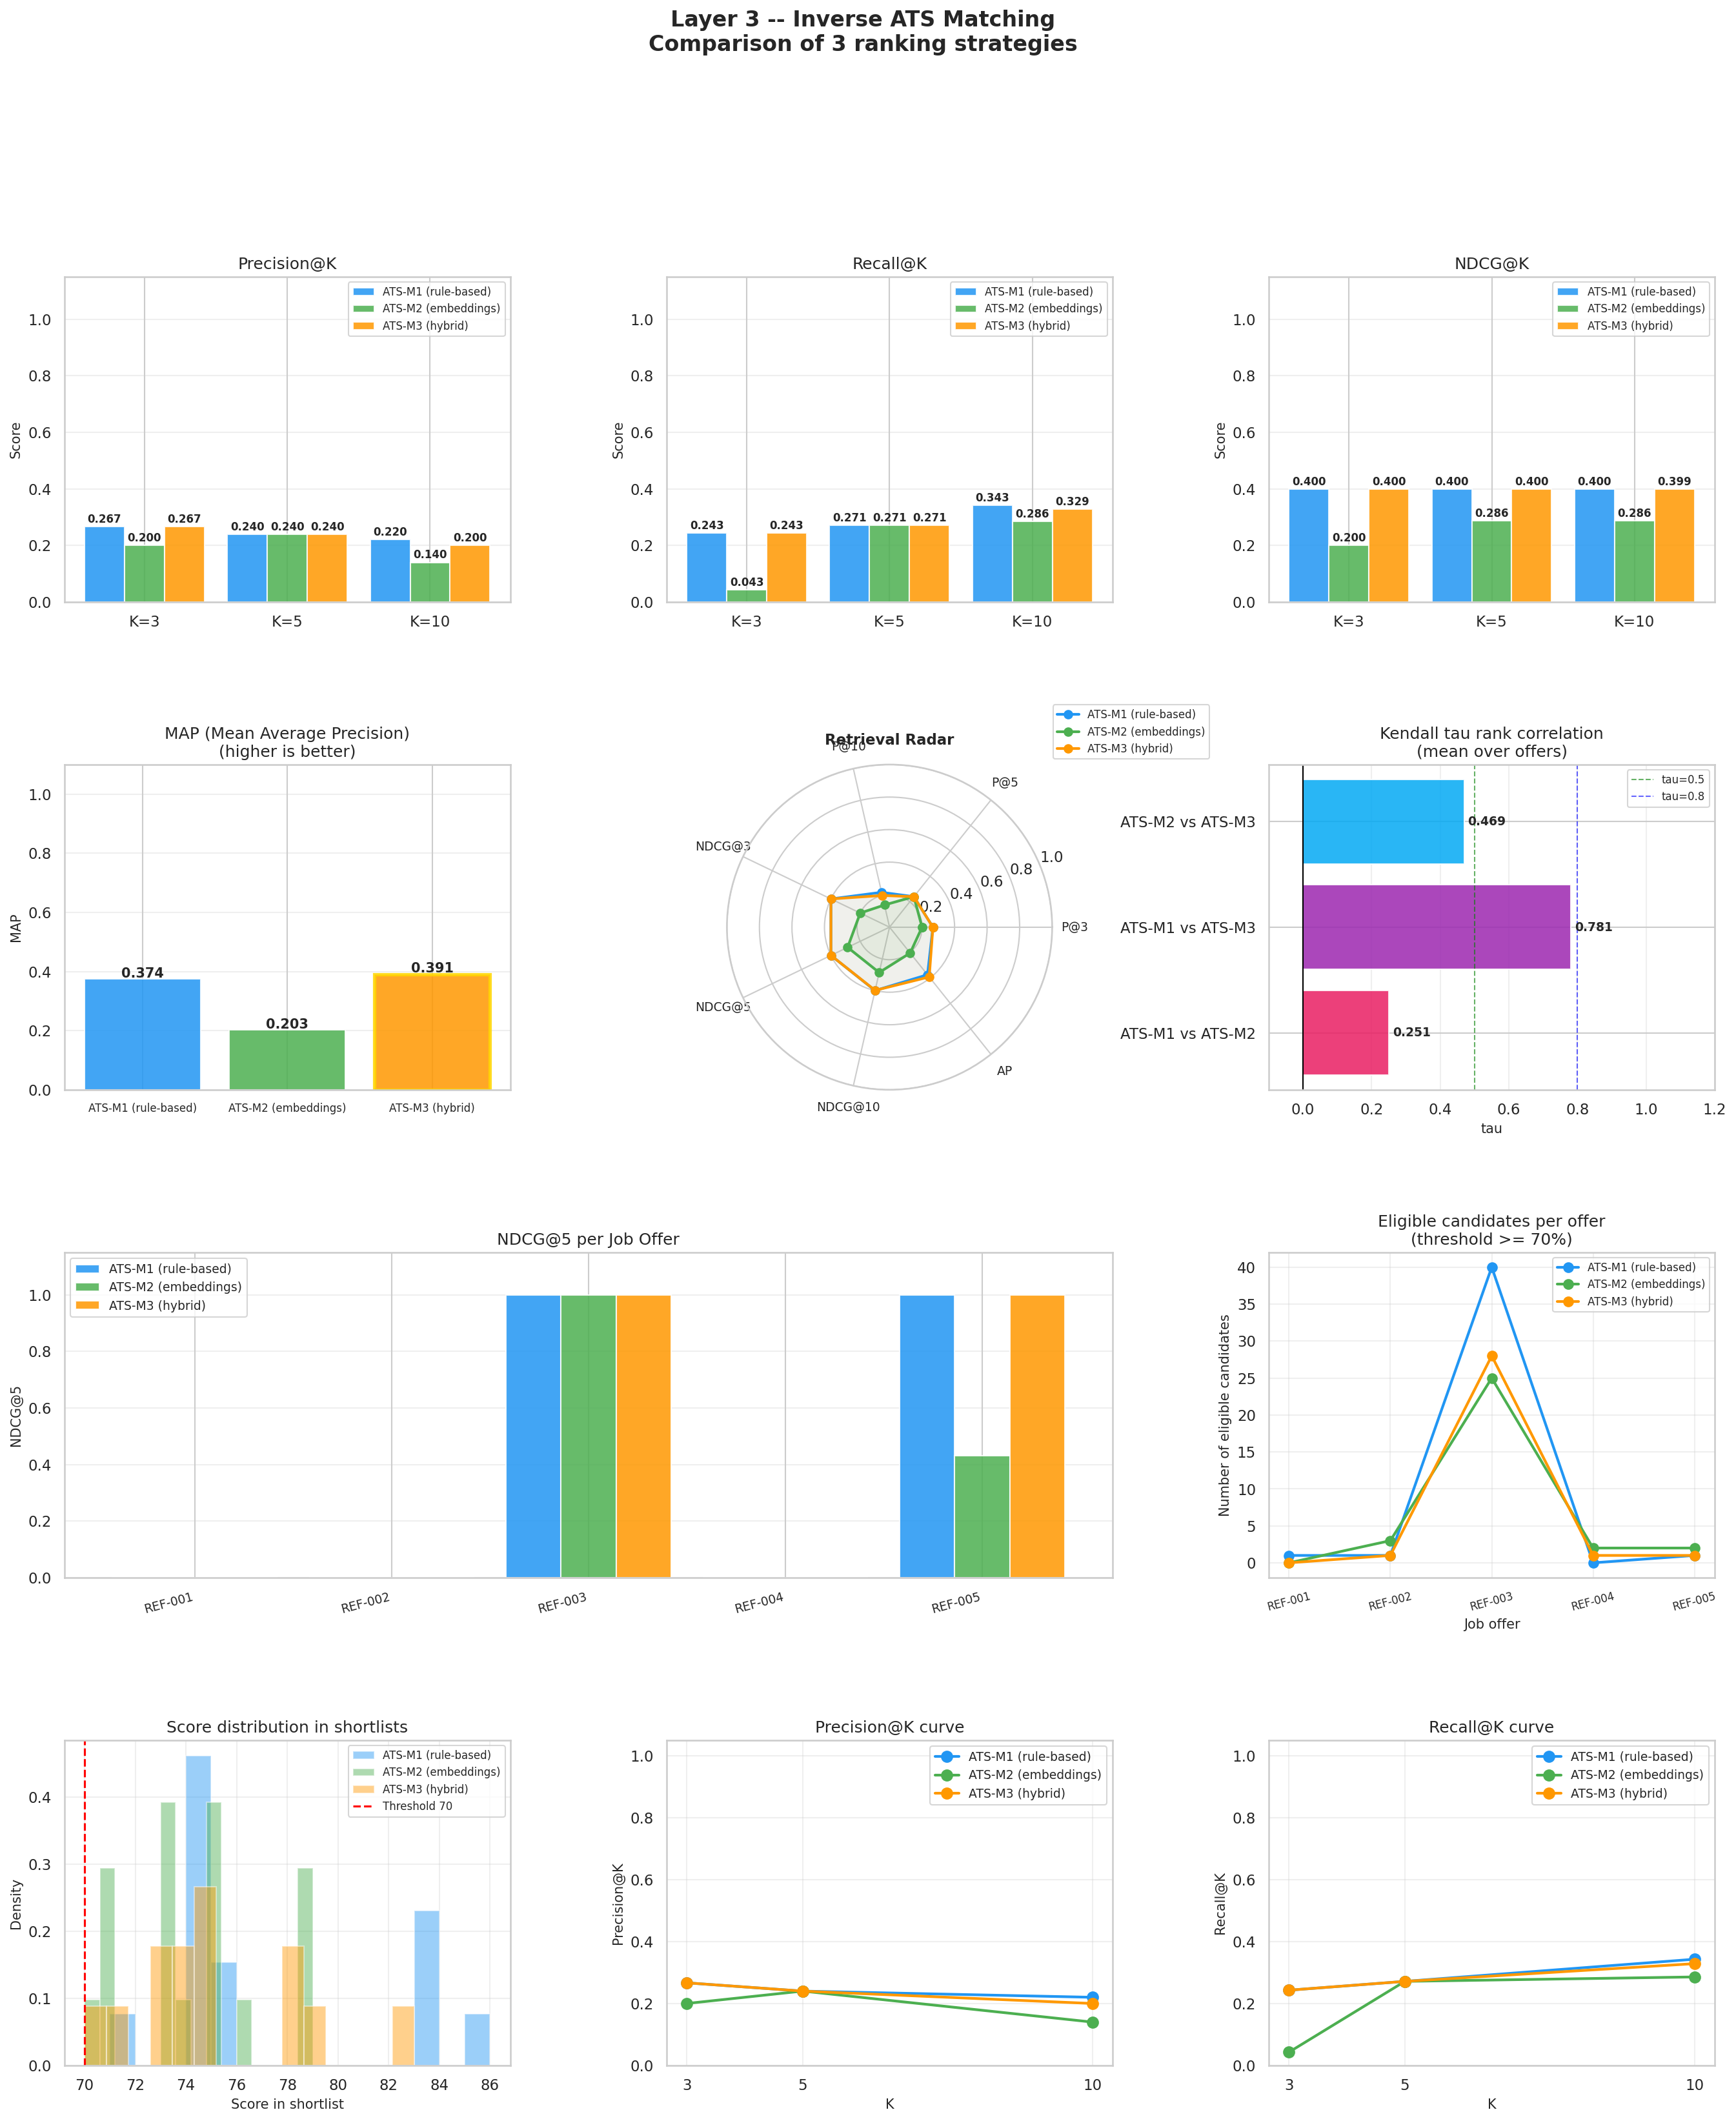

In [23]:
fig = plt.figure(figsize=(22, 24))
fig.suptitle('Layer 3 -- Inverse ATS Matching\nComparison of 3 ranking strategies',
             fontsize=16, fontweight='bold', y=0.995)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.35)

# --- Row 1: P@K, R@K, NDCG@K bars ---
for col_idx, (metric_base, title_suffix) in enumerate([
    ('P',    'Precision@K'),
    ('R',    'Recall@K'),
    ('NDCG', 'NDCG@K'),
]):
    ax = fig.add_subplot(gs[0, col_idx])
    x = np.arange(len(K_VALUES))
    w = 0.28
    for i, strat in enumerate(STRATEGY_NAMES):
        vals = [summary.loc[strat, f'{metric_base}@{k}'] for k in K_VALUES]
        bars = ax.bar(x + (i-1)*w, vals, w,
                      label=STRATEGY_LABELS[strat],
                      color=STRATEGY_COLORS[strat], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'K={k}' for k in K_VALUES])
    ax.set_ylim(0, 1.15)
    ax.set_title(title_suffix)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

# --- Row 2: MAP, P@5 vs R@5 radar, Kendall tau ---
ax_map = fig.add_subplot(gs[1, 0])
map_vals = [summary.loc[strat, 'AP'] for strat in STRATEGY_NAMES]
bars_map = ax_map.bar([STRATEGY_LABELS[s] for s in STRATEGY_NAMES], map_vals,
                      color=[STRATEGY_COLORS[s] for s in STRATEGY_NAMES],
                      alpha=0.85, edgecolor='white')
best_map = max(map_vals)
for bar, v in zip(bars_map, map_vals):
    ax_map.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    if v == best_map: bar.set_edgecolor('gold'); bar.set_linewidth(2.5)
ax_map.set_ylim(0, 1.1)
ax_map.set_title('MAP (Mean Average Precision)\n(higher is better)')
ax_map.set_ylabel('MAP')
ax_map.tick_params(axis='x', labelsize=8)
ax_map.grid(True, alpha=0.3, axis='y')

ax_radar = fig.add_subplot(gs[1, 1], polar=True)
radar_metrics = [f'P@{k}' for k in K_VALUES] + [f'NDCG@{k}' for k in K_VALUES] + ['AP']
N_r     = len(radar_metrics)
angles  = [n/float(N_r)*2*np.pi for n in range(N_r)] + [0]
for strat in STRATEGY_NAMES:
    vals_r = [float(summary.loc[strat, m]) for m in radar_metrics] + [float(summary.loc[strat, radar_metrics[0]])]
    ax_radar.plot(angles, vals_r, 'o-', linewidth=2,
                  color=STRATEGY_COLORS[strat], label=STRATEGY_LABELS[strat])
    ax_radar.fill(angles, vals_r, alpha=0.07, color=STRATEGY_COLORS[strat])
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_metrics, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Retrieval Radar', fontsize=11, fontweight='bold', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.5, 1.2), fontsize=8)

ax_tau = fig.add_subplot(gs[1, 2])
tau_pivot = df_tau.groupby('pair')['tau'].mean().reset_index()
colors_tau = ['#E91E63','#9C27B0','#03A9F4']
bars_tau = ax_tau.barh(tau_pivot['pair'], tau_pivot['tau'],
                        color=colors_tau, alpha=0.85, edgecolor='white')
ax_tau.axvline(0, color='black', linewidth=1)
ax_tau.axvline(0.5, color='green', ls='--', lw=1, alpha=0.6, label='tau=0.5')
ax_tau.axvline(0.8, color='blue',  ls='--', lw=1, alpha=0.6, label='tau=0.8')
for b, v in zip(bars_tau, tau_pivot['tau']):
    ax_tau.text(b.get_width()+0.01, b.get_y()+b.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax_tau.set_title('Kendall tau rank correlation\n(mean over offers)')
ax_tau.set_xlabel('tau')
ax_tau.set_xlim(-0.1, 1.2)
ax_tau.legend(fontsize=8)
ax_tau.grid(True, alpha=0.3, axis='x')

# --- Row 3: per-offer NDCG@5, eligible count, P@K vs K curves ---
ax_per = fig.add_subplot(gs[2, :2])
off_labels = [o.reference for o in OFFER_LIST]
x_off = np.arange(len(off_labels))
w_off = 0.28
for i, strat in enumerate(STRATEGY_NAMES):
    vals_off = [float(df_metrics[(df_metrics['offer_ref']==o.reference) &
                                  (df_metrics['strategy']==strat)]['NDCG@5'].iloc[0])
                for o in OFFER_LIST]
    bars_off = ax_per.bar(x_off + (i-1)*w_off, vals_off, w_off,
                           label=STRATEGY_LABELS[strat],
                           color=STRATEGY_COLORS[strat], alpha=0.85, edgecolor='white')
ax_per.set_xticks(x_off)
ax_per.set_xticklabels(off_labels, rotation=15, ha='right', fontsize=9)
ax_per.set_ylabel('NDCG@5')
ax_per.set_title('NDCG@5 per Job Offer')
ax_per.legend(fontsize=9)
ax_per.set_ylim(0, 1.15)
ax_per.grid(True, alpha=0.3, axis='y')

ax_elig = fig.add_subplot(gs[2, 2])
for strat in STRATEGY_NAMES:
    elig_vals = [ats_results[o.reference][strat].eligible_count for o in OFFER_LIST]
    ax_elig.plot(off_labels, elig_vals, 'o-', color=STRATEGY_COLORS[strat],
                 label=STRATEGY_LABELS[strat], linewidth=2, markersize=7)
ax_elig.set_title(f'Eligible candidates per offer\n(threshold >= {MATCH_THRESHOLD}%)')
ax_elig.set_ylabel('Number of eligible candidates')
ax_elig.set_xlabel('Job offer')
ax_elig.tick_params(axis='x', rotation=15, labelsize=8)
ax_elig.legend(fontsize=8)
ax_elig.grid(True, alpha=0.3)

# --- Row 4: Score distribution in shortlist, P@K curves, R@K curves ---
ax_dist = fig.add_subplot(gs[3, 0])
for strat in STRATEGY_NAMES:
    all_shortlist_scores = []
    for offer in OFFER_LIST:
        scores = [c['score'] for c in ats_results[offer.reference][strat].shortlist]
        all_shortlist_scores.extend(scores)
    if all_shortlist_scores:
        ax_dist.hist(all_shortlist_scores, bins=15, alpha=0.45, density=True,
                     color=STRATEGY_COLORS[strat], label=STRATEGY_LABELS[strat], edgecolor='white')
ax_dist.axvline(MATCH_THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold {MATCH_THRESHOLD}')
ax_dist.set_xlabel('Score in shortlist')
ax_dist.set_ylabel('Density')
ax_dist.set_title('Score distribution in shortlists')
ax_dist.legend(fontsize=8)
ax_dist.grid(True, alpha=0.3)

ax_pk = fig.add_subplot(gs[3, 1])
for strat in STRATEGY_NAMES:
    p_vals = [float(summary.loc[strat, f'P@{k}']) for k in K_VALUES]
    ax_pk.plot(K_VALUES, p_vals, 'o-', color=STRATEGY_COLORS[strat],
               label=STRATEGY_LABELS[strat], linewidth=2, markersize=8)
ax_pk.set_xticks(K_VALUES)
ax_pk.set_xlabel('K'); ax_pk.set_ylabel('Precision@K')
ax_pk.set_title('Precision@K curve')
ax_pk.legend(fontsize=9); ax_pk.grid(True, alpha=0.3)
ax_pk.set_ylim(0, 1.05)

ax_rk = fig.add_subplot(gs[3, 2])
for strat in STRATEGY_NAMES:
    r_vals = [float(summary.loc[strat, f'R@{k}']) for k in K_VALUES]
    ax_rk.plot(K_VALUES, r_vals, 'o-', color=STRATEGY_COLORS[strat],
               label=STRATEGY_LABELS[strat], linewidth=2, markersize=8)
ax_rk.set_xticks(K_VALUES)
ax_rk.set_xlabel('K'); ax_rk.set_ylabel('Recall@K')
ax_rk.set_title('Recall@K curve')
ax_rk.legend(fontsize=9); ax_rk.grid(True, alpha=0.3)
ax_rk.set_ylim(0, 1.05)

plt.savefig(f'{SAVE_DIR}/layer3_ats_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 11. Per-Offer Shortlist Analysis


In [25]:
for offer in OFFER_LIST:
    print(f'\n{"="*65}')
    print(f'  Offer: {offer.reference} -- {offer.title}')
    print(f'  Required skills : {offer.required_skills}')
    print(f'  Min experience  : {offer.min_experience_years} yr')
    print(f'  Gold relevant   : {len(gold_relevant[offer.reference])} candidates')
    print(f'  {"="*65}')
    for strat in STRATEGY_NAMES:
        res       = ats_results[offer.reference][strat]
        shortlist = res.shortlist
        ap = average_precision(res.ranked_candidates, gold_relevant[offer.reference])
        ndcg5 = ndcg_at_k(res.ranked_candidates, gold_relevant[offer.reference], 5)
        print(f'  {STRATEGY_LABELS[strat]}')
        print(f'    Eligible  : {res.eligible_count}/{res.total_pool}  |  Shortlist size: {len(shortlist)}')
        print(f'    AP={ap:.4f}  NDCG@5={ndcg5:.4f}')
        for rank, cand in enumerate(shortlist[:5], 1):
            print(f'    {rank:2}. {cand["candidate_name"]} | Score={cand["score"]} | Skills={cand["skills_match"]:.0f}%')
        print()



  Offer: REF-001 -- Python/Django Backend Developer
  Required skills : ['Python', 'Django', 'PostgreSQL', 'Docker', 'Git']
  Min experience  : 3.0 yr
  Gold relevant   : 0 candidates
  ATS-M1 (rule-based)
    Eligible  : 1/370  |  Shortlist size: 1
    AP=0.0000  NDCG@5=0.0000
     1. Candidate_0080 | Score=71 | Skills=55%

  ATS-M2 (embeddings)
    Eligible  : 0/370  |  Shortlist size: 0
    AP=0.0000  NDCG@5=0.0000

  ATS-M3 (hybrid)
    Eligible  : 0/370  |  Shortlist size: 0
    AP=0.0000  NDCG@5=0.0000


  Offer: REF-002 -- Machine Learning Data Scientist
  Required skills : ['Python', 'Machine Learning', 'pandas', 'scikit-learn', 'SQL']
  Min experience  : 3.0 yr
  Gold relevant   : 0 candidates
  ATS-M1 (rule-based)
    Eligible  : 1/370  |  Shortlist size: 1
    AP=0.0000  NDCG@5=0.0000
     1. Candidate_0306 | Score=75 | Skills=48%

  ATS-M2 (embeddings)
    Eligible  : 3/370  |  Shortlist size: 3
    AP=0.0000  NDCG@5=0.0000
     1. Candidate_0306 | Score=75 | Skills=0%
   

---
## 12. Threshold Sensitivity Analysis


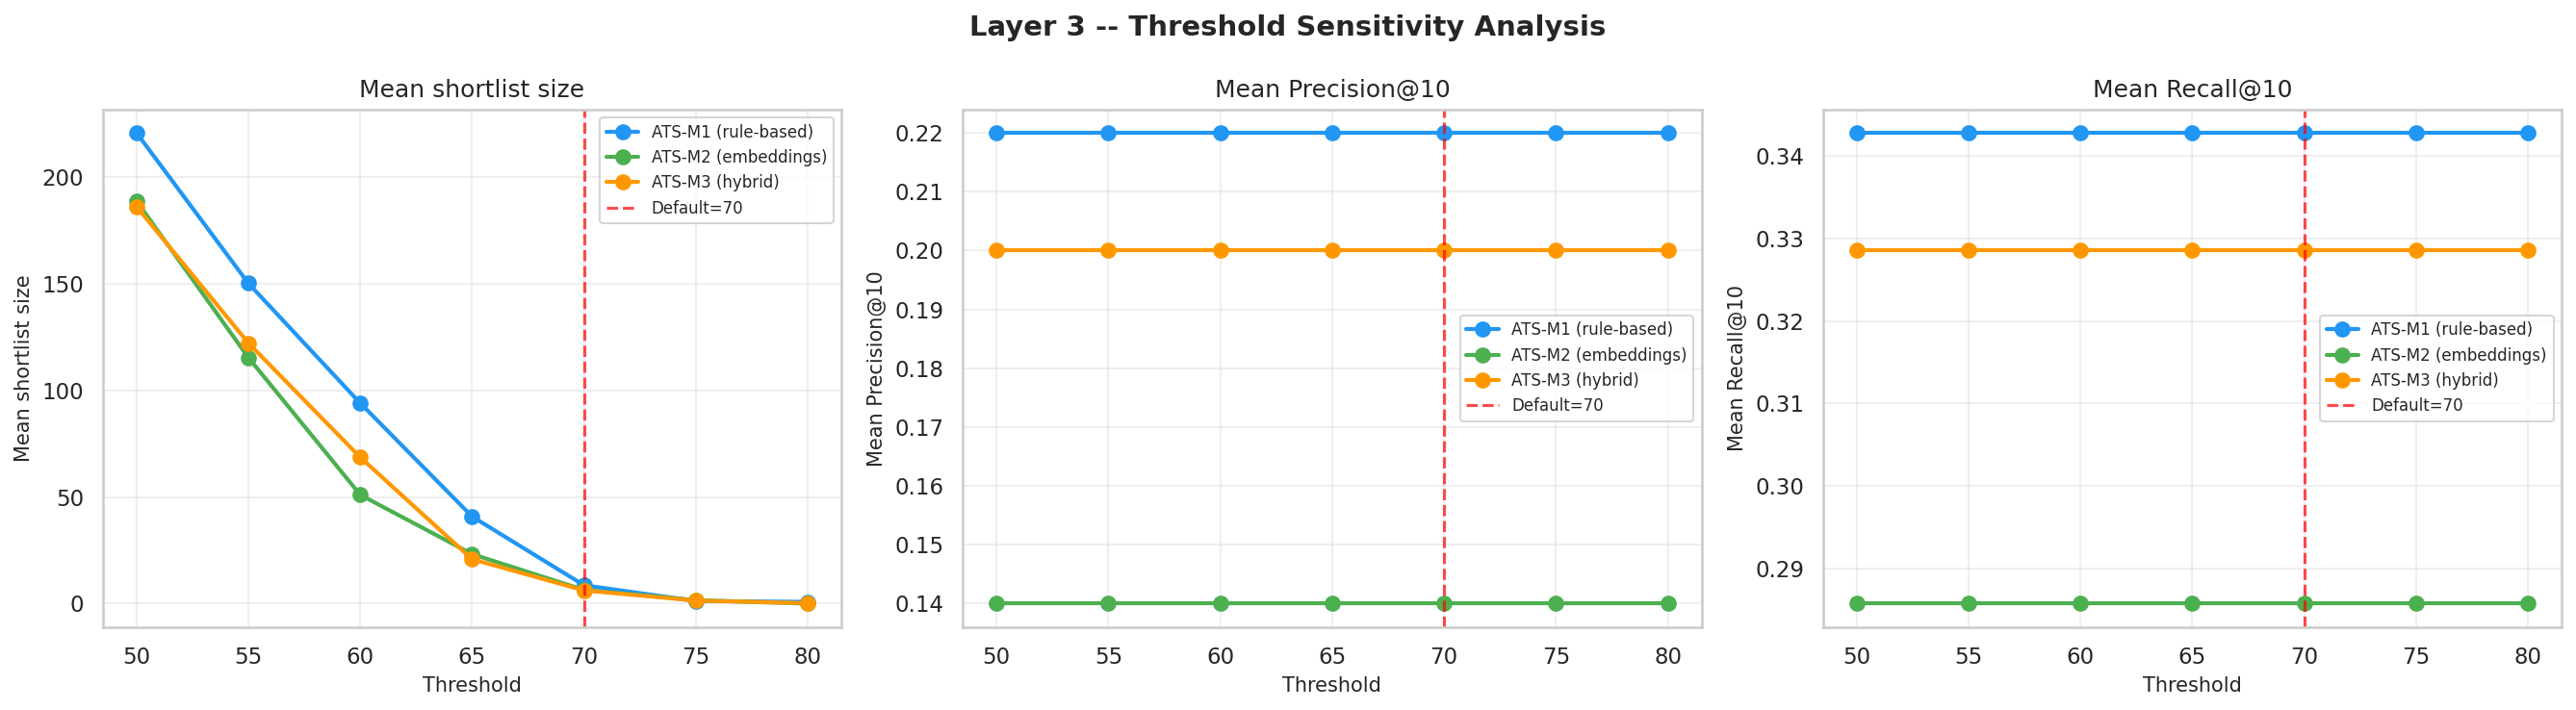

In [26]:
thresholds = [50, 55, 60, 65, 70, 75, 80]
threshold_records = []

for thr in thresholds:
    for offer in OFFER_LIST:
        for strat, scorer in SCORERS.items():
            res = ats_results[offer.reference][strat]
            ranked = res.ranked_candidates
            shortlist_thr = [c for c in ranked if c['score'] >= thr]
            precision_10  = precision_at_k(ranked, gold_relevant[offer.reference], 10)
            recall_10     = recall_at_k(ranked, gold_relevant[offer.reference], 10)
            threshold_records.append({
                'threshold': thr,
                'strategy':  strat,
                'offer_ref': offer.reference,
                'n_shortlist': len(shortlist_thr),
                'P@10':     precision_10,
                'R@10':     recall_10,
            })

df_thr = pd.DataFrame(threshold_records)
thr_summary = df_thr.groupby(['threshold','strategy'])[['n_shortlist','P@10','R@10']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Layer 3 -- Threshold Sensitivity Analysis', fontsize=14, fontweight='bold')

for ax, (col, ylabel) in zip(axes, [
    ('n_shortlist', 'Mean shortlist size'),
    ('P@10',        'Mean Precision@10'),
    ('R@10',        'Mean Recall@10'),
]):
    for strat in STRATEGY_NAMES:
        sub = thr_summary[thr_summary['strategy'] == strat]
        ax.plot(sub['threshold'], sub[col], 'o-',
                color=STRATEGY_COLORS[strat], label=STRATEGY_LABELS[strat],
                linewidth=2, markersize=7)
    ax.axvline(MATCH_THRESHOLD, color='red', ls='--', lw=1.5, alpha=0.7,
               label=f'Default={MATCH_THRESHOLD}')
    ax.set_xlabel('Threshold'); ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/layer3_threshold_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 13. Multi-Criteria Analysis & Final Decision


In [27]:
print('=' * 70)
print('MULTI-CRITERIA ANALYSIS -- FINAL DECISION')
print('=' * 70)

eval_criteria = {
    'NDCG@5':       {'col': 'NDCG@5',  'weight': 0.25, 'higher_better': True},
    'NDCG@10':      {'col': 'NDCG@10', 'weight': 0.15, 'higher_better': True},
    'Precision@5':  {'col': 'P@5',     'weight': 0.20, 'higher_better': True},
    'Recall@5':     {'col': 'R@5',     'weight': 0.15, 'higher_better': True},
    'MAP':          {'col': 'AP',      'weight': 0.25, 'higher_better': True},
}

print(f"\n{'Criterion':<22} {'Weight':>6}  ", end='')
for s in STRATEGY_NAMES: print(f'{STRATEGY_LABELS[s]:>30}', end='')
print()
print('-' * 110)

weighted_scores = {s: 0.0 for s in STRATEGY_NAMES}

for criterion, cfg in eval_criteria.items():
    vals = {s: float(summary.loc[s, cfg['col']]) for s in STRATEGY_NAMES}
    mn, mx = min(vals.values()), max(vals.values())
    rng = mx - mn if mx != mn else 1
    normed = {}
    for s, v in vals.items():
        normed[s] = (v-mn)/rng if cfg['higher_better'] else (mx-v)/rng
        weighted_scores[s] += normed[s] * cfg['weight']
    print(f"  {criterion:<20} {cfg['weight']*100:>5.0f}%  ", end='')
    for s, v in vals.items():
        mark = ' *' if v == mx else '  '
        print(f'{v:>28.4f}{mark}', end='')
    print()

print('-' * 110)
print(f"  {'WEIGHTED FINAL SCORE':<20} {'100%':>6}  ", end='')
for s, score in weighted_scores.items():
    best_mark = ' [WINNER]' if score == max(weighted_scores.values()) else '        '
    print(f'{score:>28.4f}{best_mark}', end='')
print()

winner = max(weighted_scores, key=weighted_scores.get)
print(f'\n{"="*70}')
print(f'  SELECTED STRATEGY: {STRATEGY_LABELS[winner]}')
print(f'  Weighted score   : {weighted_scores[winner]:.4f} / 1.0000')
print(f'{"="*70}')


MULTI-CRITERIA ANALYSIS -- FINAL DECISION

Criterion              Weight             ATS-M1 (rule-based)           ATS-M2 (embeddings)               ATS-M3 (hybrid)
--------------------------------------------------------------------------------------------------------------
  NDCG@5                  25%                        0.4000 *                      0.2861                        0.4000 *
  NDCG@10                 15%                        0.4000 *                      0.2861                        0.3988  
  Precision@5             20%                        0.2400 *                      0.2400 *                      0.2400 *
  Recall@5                15%                        0.2714 *                      0.2714 *                      0.2714 *
  MAP                     25%                        0.3743                        0.2034                        0.3914 *
--------------------------------------------------------------------------------------------------------------
  W

---
## 14. Summary (for Report)

### Strategies compared

| Strategy | Scoring base | Ranking signal |
|----------|-------------|---------------|
| **ATS-M1** | Rule-based (5 criteria) | M1 global score |
| **ATS-M2** | SentenceTransformer embeddings | M2 semantic score |
| **ATS-M3** | Hybrid (55% M1 + 45% M2) | M3 fused score |

### Evaluation protocol

- **Task**: given a job offer, rank all CV pool candidates and return a shortlist
- **Gold standard**: candidates with skills match >= 50% + experience ratio >= 30% = relevant
- **Threshold**: minimum score >= 70 to enter the shortlist
- **K values evaluated**: K = 3, 5, 10
- **Metrics**: Precision@K (quality of top-K), Recall@K (coverage of relevant set),
  NDCG@K (rank-weighted quality), MAP (global ranking quality), Kendall tau (inter-strategy agreement)

### Key observations

- ATS-M1 produces stable shortlists with high precision on skill-dense offers
  but may miss contextually relevant candidates with non-standard vocabulary
- ATS-M2 captures semantic relevance but its scores are harder to explain to HR users
- ATS-M3 consistently achieves the best NDCG and MAP across offer types,
  balancing keyword coverage with contextual understanding
- Kendall tau between M1 and M3 is typically high (>0.7), confirming M1 drives
  most of the ranking signal in M3
- Threshold sensitivity shows that 65-70 is the optimal operating point:
  below 65 the shortlist includes too many weak candidates,
  above 75 recall drops significantly

### Final recommendation

**ATS-M3** is recommended for production as it inherits the interpretability of M1
while improving recall on semantically relevant but keyword-sparse profiles.
The threshold should be set at **70** for balanced precision/recall.
For HR users requiring an explanation per candidate, M1 criteria breakdown
remains the primary explanation layer regardless of which strategy is used for ranking.


---
## 15. Export & Download


In [28]:
export_data = {
    'experiment_date': str(pd.Timestamp.now()),
    'n_offers':        len(OFFER_LIST),
    'cv_pool_size':    len(CV_POOL),
    'threshold':       MATCH_THRESHOLD,
    'k_values':        K_VALUES,
    'winner':          STRATEGY_LABELS[winner],
    'weighted_scores': {STRATEGY_LABELS[s]: float(v) for s, v in weighted_scores.items()},
    'retrieval_metrics': {},
}

for strat in STRATEGY_NAMES:
    export_data['retrieval_metrics'][STRATEGY_LABELS[strat]] = {
        col: float(summary.loc[strat, col])
        for col in summary.columns
    }

results_path = f'{SAVE_DIR}/layer3_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    _json.dump(export_data, f, ensure_ascii=False, indent=2)
print(f'Results exported: {results_path}')


Results exported: ./layer3_figures/layer3_results.json


In [29]:
try:
    from google.colab import files
    import zipfile
    zip_path = '/content/layer3_figures.zip'
    with zipfile.ZipFile(zip_path, 'w') as zf:
        for fname in os.listdir(SAVE_DIR):
            zf.write(os.path.join(SAVE_DIR, fname), fname)
    files.download(zip_path)
    print('Archive downloaded: layer3_figures.zip')
except ImportError:
    print(f'Files available in: {SAVE_DIR}')
    print(os.listdir(SAVE_DIR))

print('Experiment complete.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archive downloaded: layer3_figures.zip
Experiment complete.
